# SMS Spam Classification using Naive Bayes

In this notebook we will build a model that classifies SMS messages as **spam** or **ham** (not spam) using the **Naive Bayes** algorithm.

The dataset used is the **SMS Spam Collection** (5,572 labelled messages), originally from UCI. It was downloaded once from a public mirror and saved locally as `spam.csv`.

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\z_Learn\miraj_pandas\Machine Learning\Naive Bayse\spam.csv')
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
df.describe(include='object')

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 403


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(5169, 2)

## EDA

In [9]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

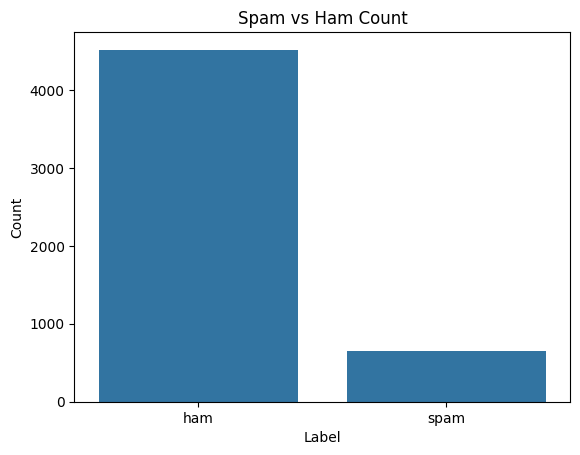

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

The dataset is **imbalanced** — there are far more ham messages than spam. We'll keep an eye on **precision & recall** instead of relying only on accuracy.

In [11]:
df['length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df.head()

,label,message,length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


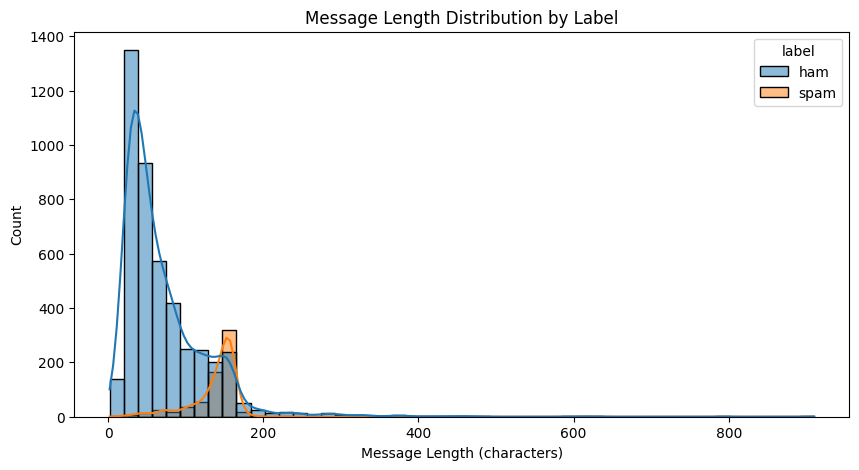

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution by Label')
plt.xlabel('Message Length (characters)')
plt.show()

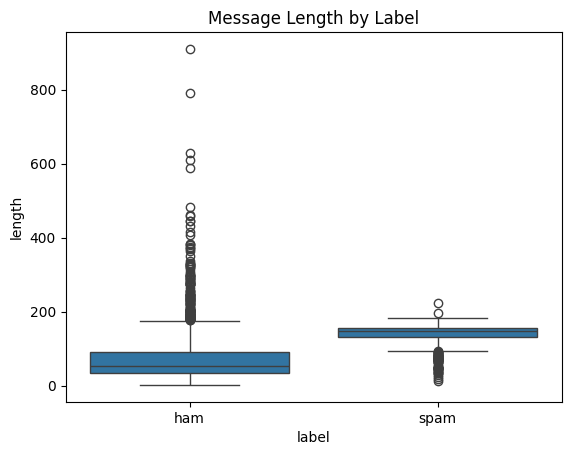

In [13]:
sns.boxplot(data=df, x='label', y='length')
plt.title('Message Length by Label')
plt.show()

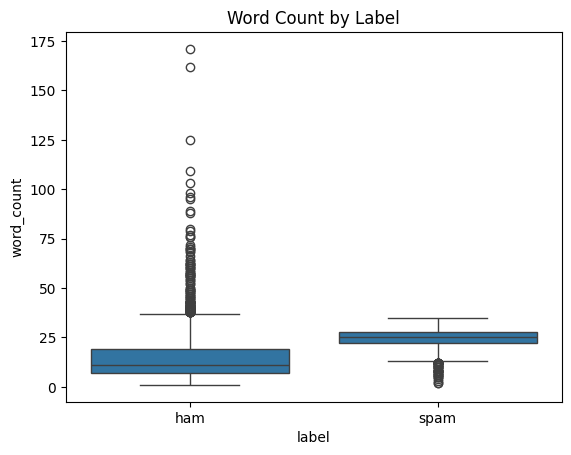

In [14]:
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Word Count by Label')
plt.show()

**Observation:** Spam messages tend to be **longer** and have **more words** than ham messages. Spam usually contains promotional content like "FREE", "WIN", "CLAIM", phone numbers, URLs, etc.

In [15]:
print('--- Sample SPAM messages ---')
for msg in df[df['label']=='spam']['message'].head(5):
    print('*', msg)
    print()

--- Sample SPAM messages ---
* Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

* FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

* WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

* Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030

* SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info



In [16]:
print('--- Sample HAM messages ---')
for msg in df[df['label']=='ham']['message'].head(5):
    print('*', msg)
    print()

--- Sample HAM messages ---
* Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

* Ok lar... Joking wif u oni...

* U dun say so early hor... U c already then say...

* Nah I don't think he goes to usf, he lives around here though

* Even my brother is not like to speak with me. They treat me like aids patent.



## Label Encoding

Convert `ham` → 0 and `spam` → 1.

In [17]:
df['label_num'] = (df['label'] == 'spam').astype(int)
df[['label', 'label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


## Splitting the data for training

In [18]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1,
                                                    stratify=y)

print('the shape of the train data set is : ', X_train.shape)
print('the shape of the test data set is : ', X_test.shape)

the shape of the train data set is :  (3618,)
the shape of the test data set is :  (1551,)


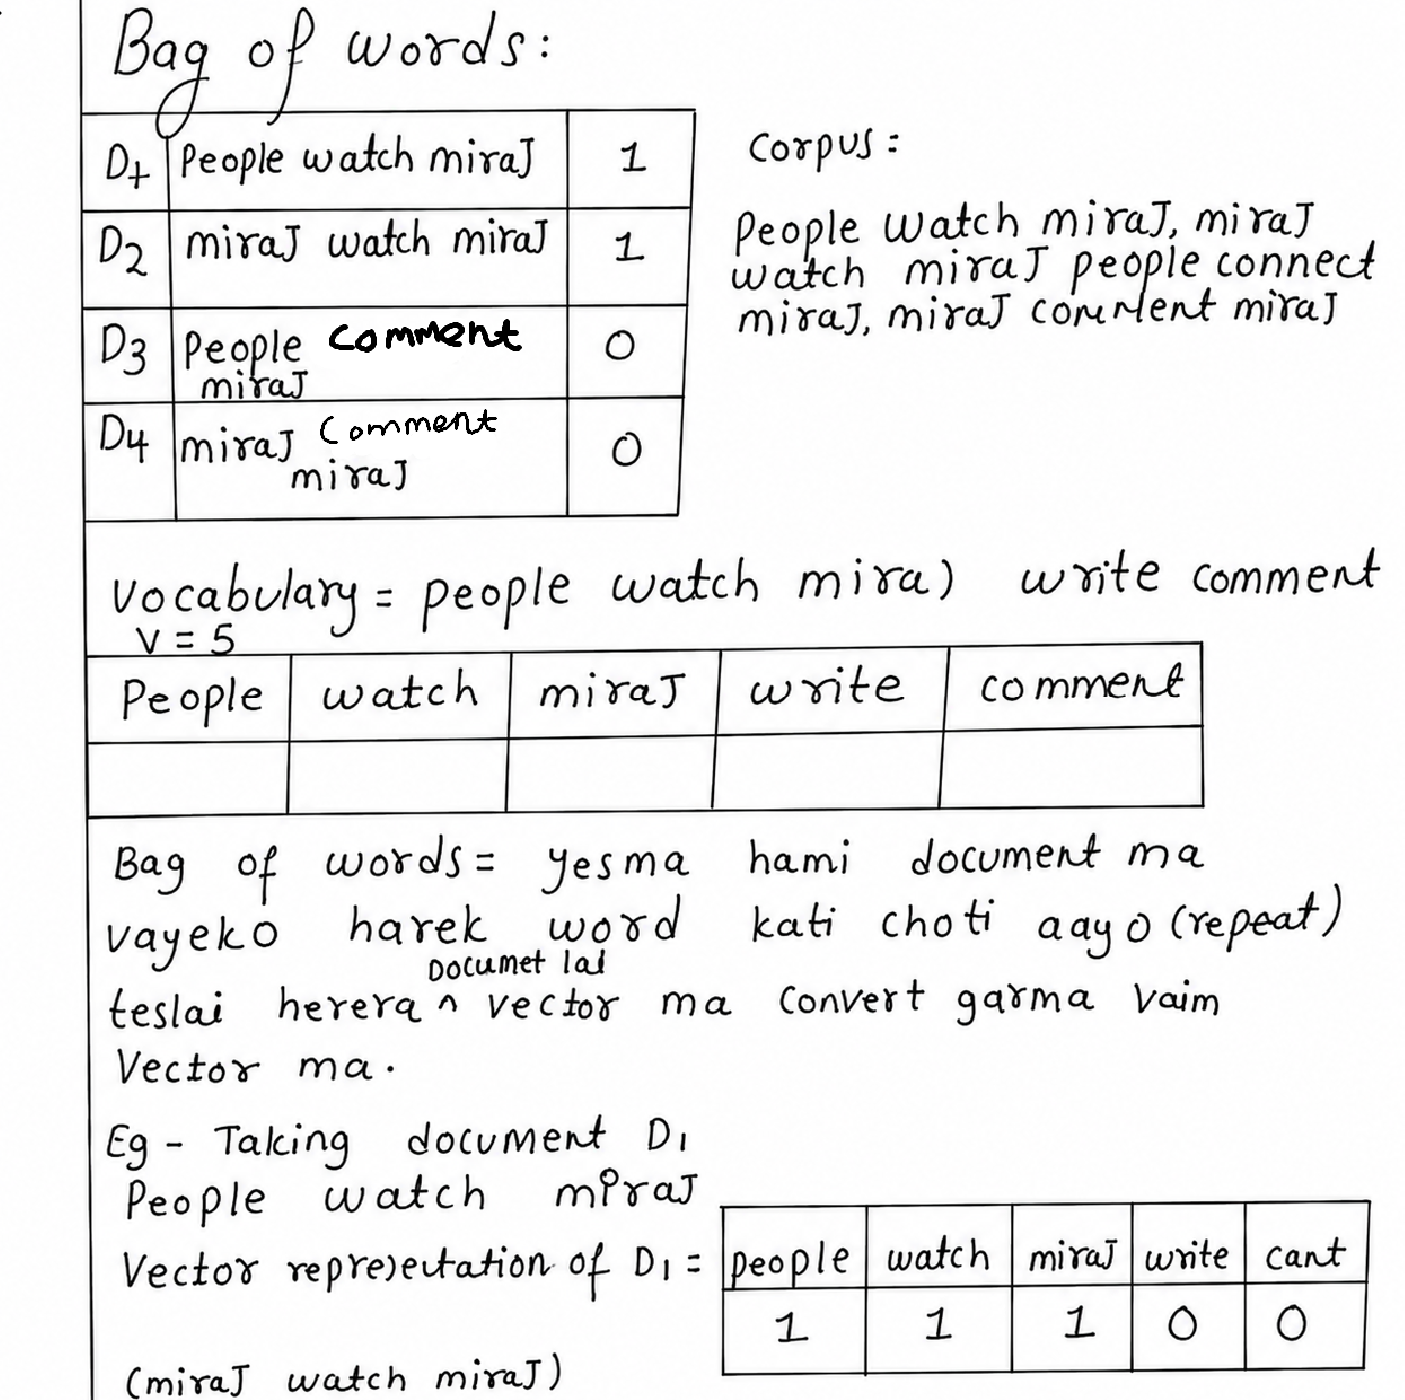

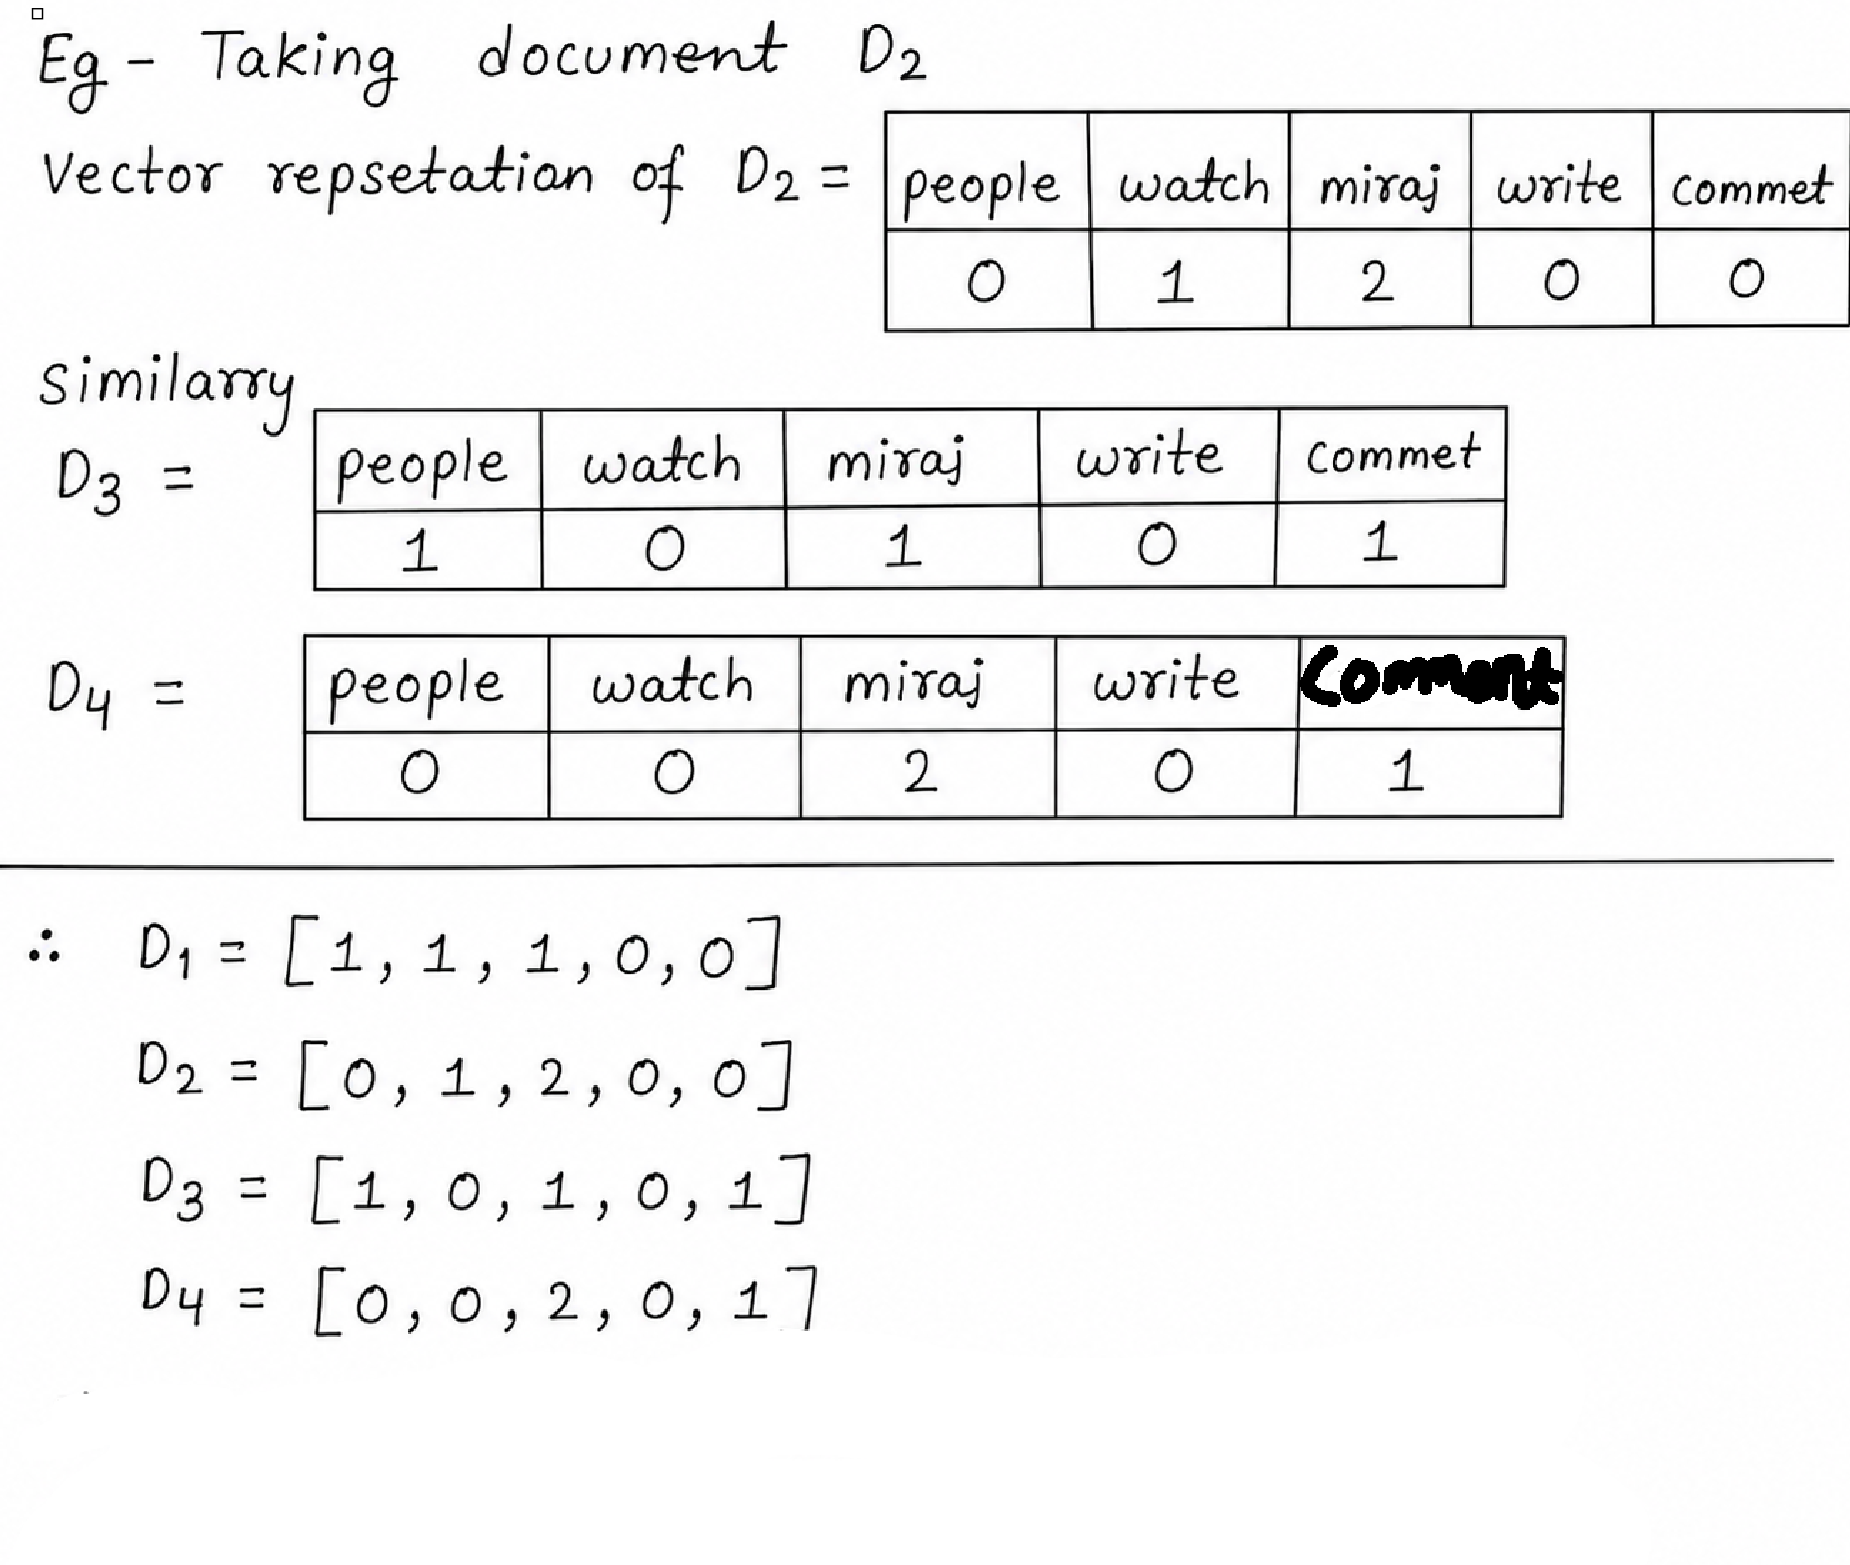

### Mini Live Demo

Let's actually run CountVectorizer on the two tiny example messages above and inspect the dict + the vector it produces.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
demo_messages = ['win free prize', 'hello friend free']

demo_cv = CountVectorizer()
demo_matrix = demo_cv.fit_transform(demo_messages)
import pandas as pd
pd.DataFrame(demo_matrix.toarray(),
             columns=demo_cv.get_feature_names_out(),
             index=demo_messages)

,free,friend,hello,prize,win
win free prize,1,0,0,1,1
hello friend free,1,1,1,0,0


In [27]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

print('Vocabulary size :', len(cv.vocabulary_))
print('X_train_vec shape:', X_train_vec.shape)
print('X_test_vec shape :', X_test_vec.shape)

Vocabulary size : 6877
X_train_vec shape: (3618, 6877)
X_test_vec shape : (1551, 6877)


## Naive Bayes Classifier

**Naive Bayes** is a probabilistic classifier based on **Bayes' Theorem** with a **"naive" assumption** that all features are independent of each other.

### Bayes' Theorem

```
P(Class | Features) = P(Features | Class) * P(Class) / P(Features)
```

For spam classification, we want to compute:

- `P(spam | message)` = probability the message is spam given its words
- `P(ham  | message)` = probability the message is ham given its words

Whichever is higher → that is the predicted class.

### The "Naive" Assumption

Naive Bayes assumes every word in the message appears **independently** of every other word.

So for a message with words `w1, w2, w3, ...`:

```
P(spam | w1,w2,w3) ∝ P(spam) * P(w1|spam) * P(w2|spam) * P(w3|spam)
```

This is obviously wrong in reality (words *do* depend on each other) — that's why it's called *naive* — but it works surprisingly well in practice for text classification.

In [30]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

In [31]:
for actual, pred in list(zip(y_test[:10], y_pred[:10])):
    a = 'spam' if actual == 1 else 'ham'
    p = 'spam' if pred == 1 else 'ham'
    print(f'Actual: {a:5s} | Predicted: {p}')

Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham
Actual: spam  | Predicted: spam
Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham
Actual: ham   | Predicted: ham


In [32]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9877


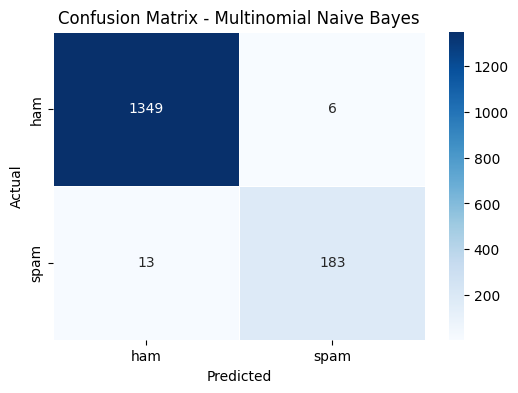

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'],
            linewidths=0.5)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1355
        spam       0.97      0.93      0.95       196

    accuracy                           0.99      1551
   macro avg       0.98      0.96      0.97      1551
weighted avg       0.99      0.99      0.99      1551



### Which metric matters most here?

For spam filters, **Precision on the spam class** is usually the most important metric.

- A **False Positive** (a real important email/SMS marked as spam) is very costly — the user may miss it.
- A **False Negative** (a spam message that slips through to the inbox) is annoying but not dangerous.

So we want **high precision** on spam → when the model says SPAM, it should almost always be correct.

## Inference on Custom Messages

In [36]:
def predict_spam(message):
    vec = cv.transform([message])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    label = 'SPAM' if pred == 1 else 'HAM'
    return f'{label}  (ham={proba[0]:.3f}, spam={proba[1]:.3f})  ->  {message}'

In [39]:
test_messages = [
    'Congratulations! You have won a FREE iPhone. Click here to claim your prize now!',
    'Hey, are we still meeting for lunch tomorrow at 1pm?',
    'URGENT: Your account has been suspended. Reply YES to reactivate.',
    'Mom, I will be home late tonight. Don\'t wait up.',
    'WINNER!! You have been selected to receive a $1000 cash prize. Call 09061701461 now.',
    'Can you send me the project report by EOD?',
]

for msg in test_messages:
    print(predict_spam(msg))
    print()

SPAM  (ham=0.000, spam=1.000)  ->  Congratulations! You have won a FREE iPhone. Click here to claim your prize now!

HAM  (ham=1.000, spam=0.000)  ->  Hey, are we still meeting for lunch tomorrow at 1pm?

SPAM  (ham=0.039, spam=0.961)  ->  URGENT: Your account has been suspended. Reply YES to reactivate.

HAM  (ham=1.000, spam=0.000)  ->  Mom, I will be home late tonight. Don't wait up.

SPAM  (ham=0.000, spam=1.000)  ->  WINNER!! You have been selected to receive a $1000 cash prize. Call 09061701461 now.

HAM  (ham=0.985, spam=0.015)  ->  Can you send me the project report by EOD?



In [37]:
input_ = input("Enter a message to check if it's SPAM or HAM: ")
result = predict_spam(input_)
print(result)

SPAM  (ham=0.000, spam=1.000)  ->  Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030


In [41]:
# Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030

## Conclusion

- **Multinomial Naive Bayes** combined with a simple **Bag of Words** representation reaches around **98%+ accuracy** on the SMS Spam Collection dataset.
- It is **fast, simple and very interpretable** — making it a great baseline for any text classification problem.
- The model successfully picks up classic spam signals like *FREE, WIN, URGENT, CLAIM, $* and large numbers.
- Further improvements could come from using **TF-IDF** instead of raw counts, or trying **BernoulliNB**, **Logistic Regression** or modern transformer-based models.